# **EDA & DATA ANALYSIS**

## **Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

ModuleNotFoundError: No module named 'seaborn'

In [4]:
df = pd.read_csv("../data/raw/dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     4021 non-null   str    
 1   usd_vnd  4021 non-null   float64
 2   vix      4021 non-null   float64
 3   wti_oil  4021 non-null   float64
 4   us_10y   4021 non-null   float64
 5   dxy      4021 non-null   float64
 6   vnindex  4021 non-null   float64
dtypes: float64(6), str(1)
memory usage: 220.0 KB


## **Data Description**

In [5]:
#Convert to Datetime
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Number of observations:", len(df))

Start date: 2010-01-04 00:00:00
End date: 2025-12-31 00:00:00
Number of observations: 4021


## **Data Description**
| Column | Type | Unit / Scale | Description | Expected Use |
|---|---|---|---|---|
| `Date` | Datetime | Daily date | The date corresponding to each observation in the dataset. | Used as the time index for time-series analysis. |
| `usd_vnd` | Numeric | VND per USD | The nominal exchange rate between the U.S. dollar and Vietnamese dong. A higher value indicates depreciation of the Vietnamese dong against the U.S. dollar. | Main dependent variable in the research. |
| `vix` | Numeric | Index value | The VIX measures expected volatility in the U.S. stock market and is commonly used as a proxy for global risk and uncertainty. | Key explanatory variable capturing global uncertainty shocks. |
| `us_10y` | Numeric | Percent yield | The 10-year U.S. Treasury yield, representing long-term U.S. interest rate conditions. | Explanatory variable capturing global interest rate shocks. |
| `dxy` | Numeric | Index value | The U.S. Dollar Index measures the overall strength of the U.S. dollar relative to a basket of major currencies. | Explanatory variable capturing external USD strength. |
| `vnindex` | Numeric | Index value | The main stock market index of Vietnam, reflecting domestic equity market performance. | Control variable for domestic financial market conditions. |

## **Data Overview**

### **Duplicate check**

In [6]:
duplicate_dates = df["Date"].duplicated().sum()
print("Number of duplicated dates:", duplicate_dates)

Number of duplicated dates: 0


### **Missing value check**

In [7]:
missing_count = df.isna().sum()
missing_percent = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
Date,0,0.0
usd_vnd,0,0.0
vix,0,0.0
wti_oil,0,0.0
us_10y,0,0.0
dxy,0,0.0
vnindex,0,0.0


### **Outlier IQR**

In [8]:
outlier_rows = []

# Select only numeric columns (exclude Date)
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    series = df[col].dropna()
    
    if len(series) == 0:
        continue
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    outlier_pct = outlier_count / len(series) * 100
    
    outlier_rows.append({
        "column_name": col,
        "q1": round(q1, 4),
        "q3": round(q3, 4),
        "iqr": round(iqr, 4),
        "lower_bound": round(lower_bound, 4),
        "upper_bound": round(upper_bound, 4),
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_rows)

outlier_df = outlier_df.sort_values(
    by="outlier_pct",
    ascending=False
)

print("Outlier summary:")
display(outlier_df)

Outlier summary:


,column_name,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
1,vix,13.7700,21.1200,7.3500,2.7450,32.1450,173,4.30
2,wti_oil,54.1800,88.2200,34.0400,3.1200,139.2800,1,0.02
0,usd_vnd,21103.7248,23312.7404,2209.0156,17790.2014,26626.2638,0,0.00
3,us_10y,1.8700,3.3500,1.4800,-0.3500,5.5700,0,0.00
4,dxy,82.5500,99.1800,16.6300,57.6050,124.1250,0,0.00
5,vnindex,527.9700,1141.4200,613.4500,-392.2050,2061.5950,0,0.00


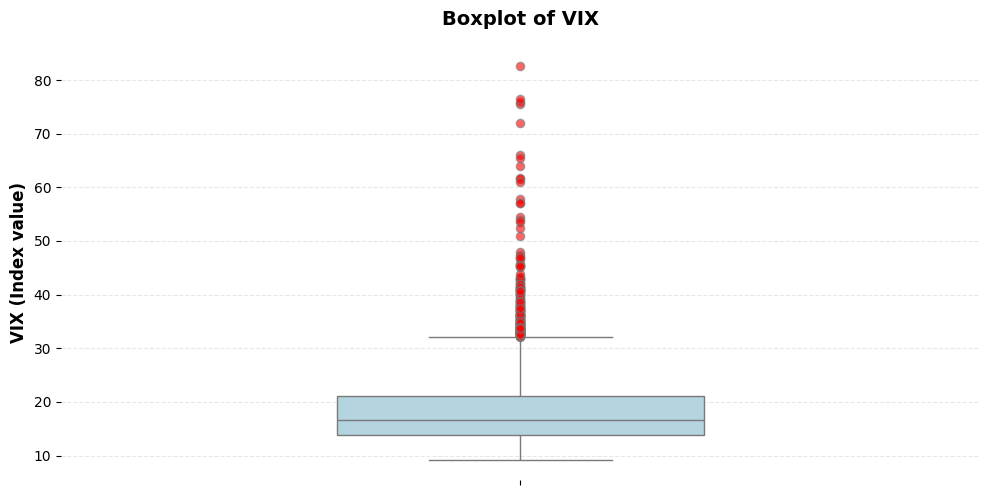

In [9]:
plt.figure(figsize=(10, 5))

# Create boxplot with custom styling
sns.boxplot(data=df, y='vix', 
            color='lightblue', 
            width=0.4,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6))

# Remove all spines (black borders)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Styling
plt.title("Boxplot of VIX", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("VIX (Index value)", fontsize=12, fontweight='bold')
plt.xlabel("")

plt.tight_layout()
plt.show()

### **Descriptive statistics**

In [10]:
numeric_cols = ["usd_vnd", "vix", "us_10y", "dxy", "vnindex"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
usd_vnd,4021.0,22538.954210,1703.352095,18469.00,21103.724807,22732.439191,23312.740413,26434.047053
vix,4021.0,18.418801,6.876434,9.14,13.770000,16.680000,21.120000,82.690000
us_10y,4021.0,2.611423,1.003484,0.52,1.870000,2.460000,3.350000,4.980000
dxy,4021.0,92.743554,9.369933,72.93,82.550003,95.120003,99.180000,114.110001
vnindex,4021.0,853.233193,350.104759,336.73,527.970000,827.720000,1141.420000,1784.490000


## **Variables Analysis**

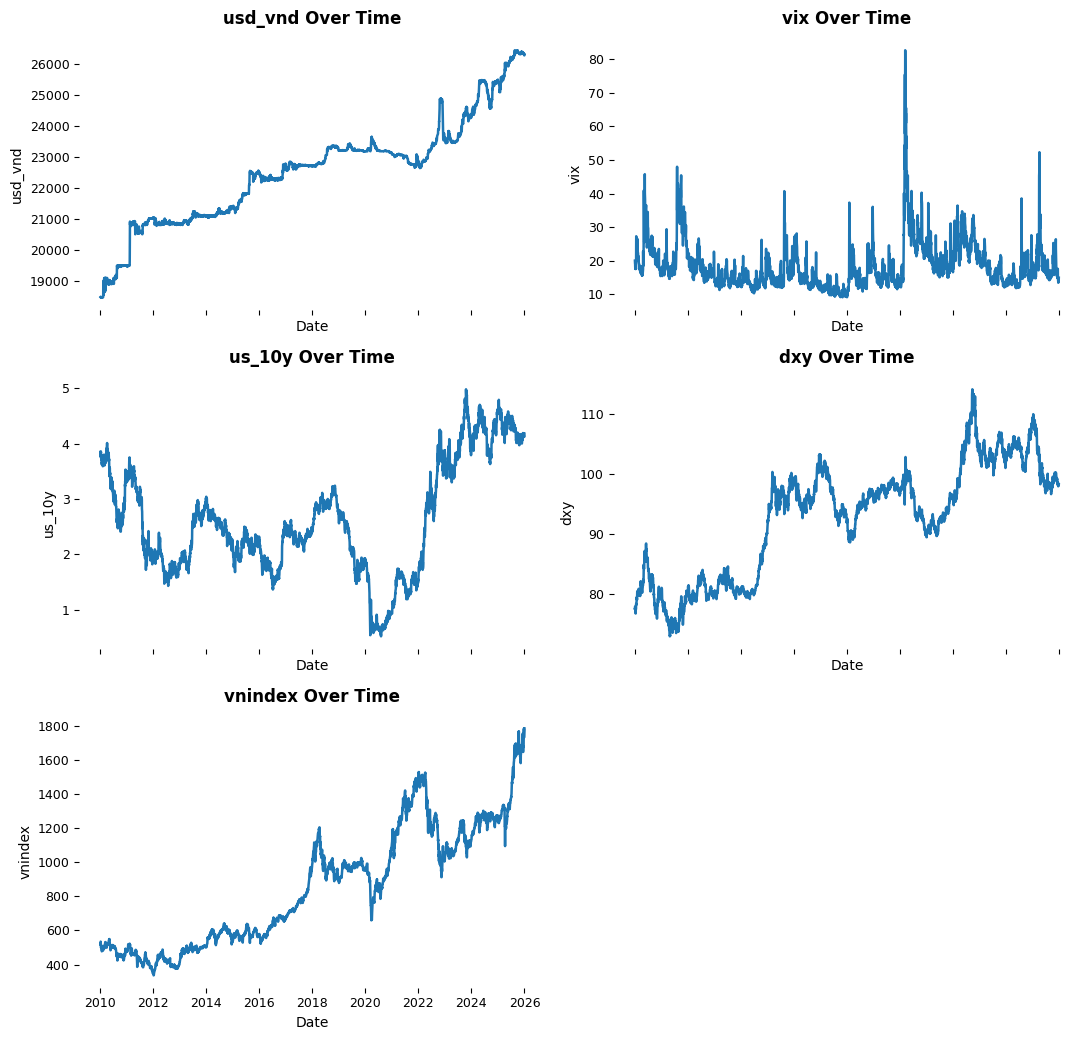

In [11]:
plt.style.use("default")

# Đảm bảo Date đúng kiểu thời gian
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Số biểu đồ
n_plots = len(numeric_cols)

# Xếp thành 3 hàng
n_rows = 3
n_cols = math.ceil(n_plots / n_rows)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 3.5 * n_rows),
    sharex=True
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    ax.plot(
        df["Date"],
        df[col],
        color="#1f77b4",
        linewidth=1.8
    )

    ax.set_title(
        f"{col} Over Time",
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel(col, fontsize=10)

    ax.set_facecolor("white")

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis="both", labelsize=9)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.patch.set_facecolor("white")

plt.tight_layout()
plt.show()

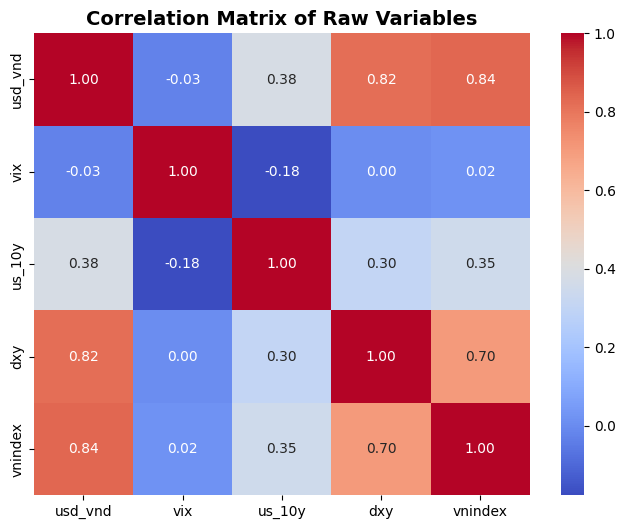

In [12]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Raw Variables", fontsize=14, fontweight='bold')
plt.show()

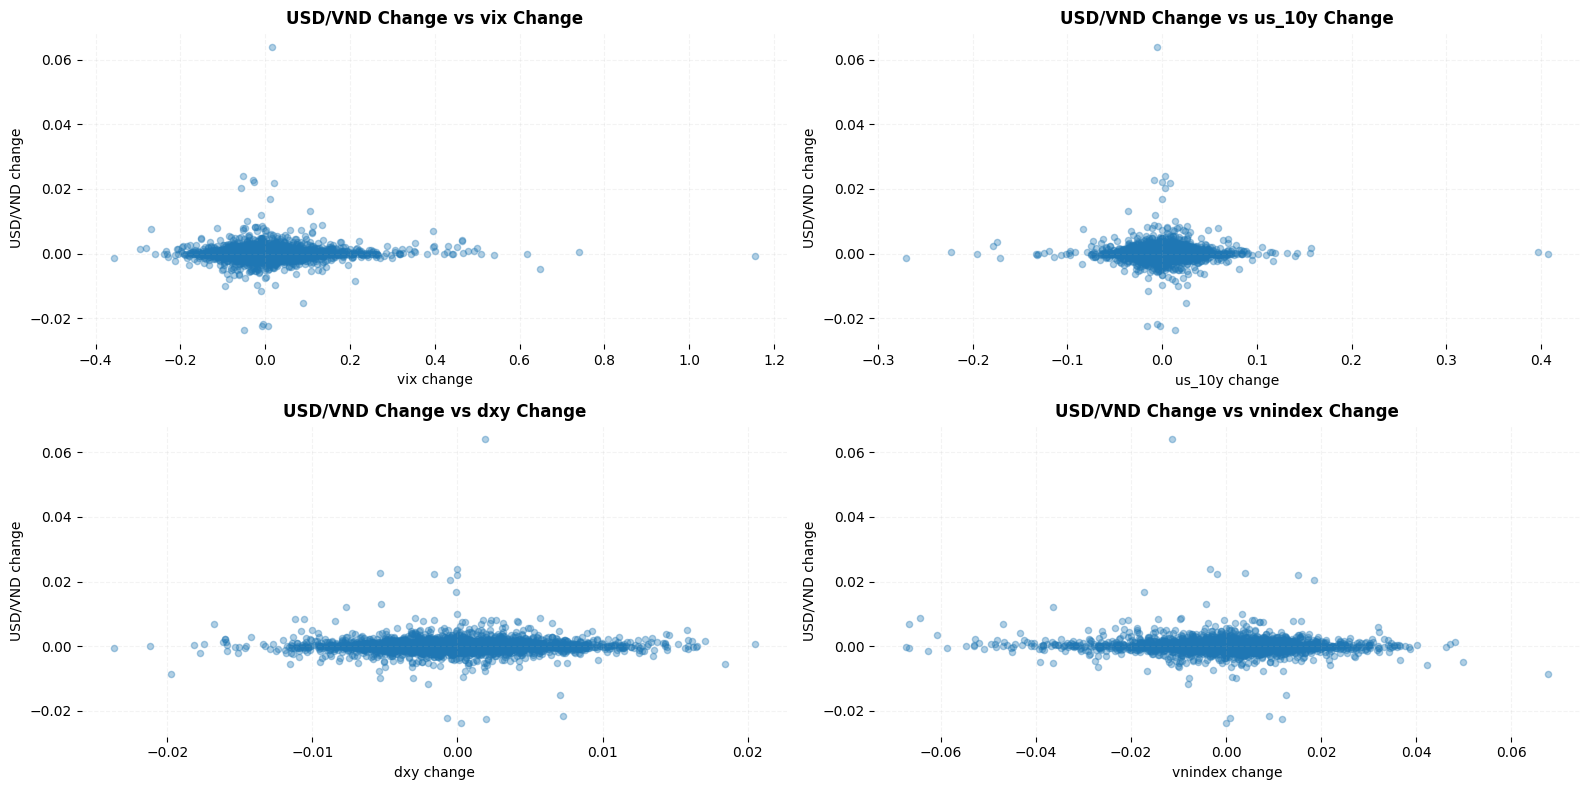

In [13]:
plt.style.use("default")

shock_vars = ["vix", "us_10y", "dxy", "vnindex"]

plot_df = df[["usd_vnd"] + shock_vars].copy()
plot_df = plot_df.pct_change().dropna()

n_cols = 2
n_rows = math.ceil(len(shock_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(shock_vars):
    ax = axes[i]

    ax.scatter(
        plot_df[col],
        plot_df["usd_vnd"],
        alpha=0.35,
        s=20
    )

    ax.set_title(f"USD/VND Change vs {col} Change", fontsize=12, fontweight="bold")
    ax.set_xlabel(f"{col} change")
    ax.set_ylabel("USD/VND change")

    ax.set_facecolor("white")
    ax.grid(True, alpha=0.15, linestyle="--")

    for spine in ax.spines.values():
        spine.set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()